#### 环境配置--绘图：
- plt.rcParams 的设置是全局生效的。
- 如果你在后面的代码中再次调用了 sns.set_theme() 或者 plt.rc_context()，可能会覆盖掉之前的设置。

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import fontManager

# 1. 先设置 Seaborn 主题
sns.set_theme(style="ticks")

# 2. 强行刷新并指定中文字体（按优先级排序）
# Windows 常用：SimHei (黑体), Microsoft YaHei (微软雅黑), SimSun (宋体)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 修复负号显示

# 3. (可选) 打印一下当前系统实际调用的字体，用于排查
print(f"当前生效字体: {plt.rcParams['font.sans-serif'][0]}")

### 1.数据清洗与目标变量计算

In [ ]:
import pandas as pd
# 随便读取合并前的一个核心文件看一眼
df_temp1 = pd.read_csv('../data/merged_daily.csv', nrows=3)
df_temp2 = pd.read_csv('../data/merged_daily_gemini-1.5-flash_opinion.csv', nrows=3)
print(df_temp1.columns.tolist())
print(df_temp2.columns.tolist())

['timestamp', 'open', 'close', 'high', 'low', 'volume', 'blocks-size', 'avg-block-size', 'n-transactions-total', 'n-transactions-per-block', 'hash-rate', 'difficulty', 'miners-revenue', 'transaction-fees-usd', 'n-unique-addresses', 'n-transactions', 'estimated-transaction-volume-usd', 'total-bitcoins', 'market-cap', 'fng_value', 'fng_value_classification', 'fng_sentiment', 'cbbi_value', 'cbbi_sentiment', 'cointelegraph', 'bitcoin_news', 'reddit', 'avg_current_price', 'avg_next_price', 'pct_price_change', 'trend']
['timestamp', 'open', 'close', 'high', 'low', 'volume', 'blocks-size', 'avg-block-size', 'n-transactions-total', 'n-transactions-per-block', 'hash-rate', 'difficulty', 'miners-revenue', 'transaction-fees-usd', 'n-unique-addresses', 'n-transactions', 'estimated-transaction-volume-usd', 'total-bitcoins', 'market-cap', 'fng_value', 'fng_value_classification', 'fng_sentiment', 'cbbi_value', 'cbbi_sentiment', 'cointelegraph', 'bitcoin_news', 'reddit', 'avg_current_price', 'avg_next

In [ ]:
import pandas as pd
import numpy as np
import os


# ==========================================
# 1. 数据加载与合并
# ==========================================

# 确保读取路径符合本地项目文件结构规范
path_base = '../data/merged_daily.csv'
path_llm = '../data/merged_daily_gemini-1.5-flash_opinion.csv'

# 读取两份数据
df_base = pd.read_csv(path_base)
df_llm = pd.read_csv(path_llm)

# 将 timestamp 列转换为 datetime 格式
df_base['timestamp'] = pd.to_datetime(df_base['timestamp'])
df_llm['timestamp'] = pd.to_datetime(df_llm['timestamp'])

# 按时间正序排列（防止原始数据乱序导致时序特征错乱）
df_base = df_base.sort_values('timestamp').reset_index(drop=True)
df_llm = df_llm.sort_values('timestamp').reset_index(drop=True)

# 提取两份数据的公共列名。
# 因为 df_llm 包含了 df_base 的所有基础列，为避免合并时产生多余的 _x, _y 后缀，
# 我们直接对所有公共列和 timestamp 进行内连接合并（取交集），以保留完整的标注特征对齐数据。
common_cols = list(set(df_base.columns) & set(df_llm.columns))
df_merged = pd.merge(df_base, df_llm, on=common_cols, how='inner')

# ==========================================
# 2. 缺失值处理（严禁未来数据穿越）
# ==========================================

# 统一使用前向填充（ffill）来处理所有特征列的缺失值，利用历史最新可用数据填充
df_merged = df_merged.ffill()

# 如果最开头存在无法通过前向填充的 NaN（即第一天就有缺失），直接将其丢弃
df_merged = df_merged.dropna().reset_index(drop=True)

# ==========================================
# 3. 目标变量构建（核心）
# ==========================================

# 计算当天的 Parkinson 极值波动率 V_P
# 公式：V_P = (ln(H_t / L_t))^2 / (4 * ln(2))
# 注：在此步操作前，确保 high 和 low 不存在 <= 0 的异常值
ln_hl = np.log(df_merged['high'] / df_merged['low'])
v_p = (ln_hl ** 2) / (4 * np.log(2))

# 取自然对数，得到对数波动率 sigma_t
# 加入极小值 epsilon=1e-8，防止极端情况（某天高低点完全一样时 v_p=0）导致计算出 -inf，破坏后续网络训练
epsilon = 1e-8
sigma_t = np.log(v_p + epsilon)

# 防穿越后移：将当天的对数波动率向上平移一行，作为前一天的次日预测目标
df_merged['target_sigma_t_plus_1'] = sigma_t.shift(-1)

# 平移操作会导致最后一天缺少次日的数据（产生 NaN），必须删除这最后一行
df_merged = df_merged.dropna(subset=['target_sigma_t_plus_1']).reset_index(drop=True)

# ==========================================
# 4. 数据导出与结果校验
# ==========================================

# 检查目标文件夹是否存在，不存在则创建
os.makedirs('../data', exist_ok=True)

# 将预处理完的数据导出为 CSV，作为后续 PyTorch 建模的基准数据
output_path = '../data/01_preprocessed_data.csv'
df_merged.to_csv(output_path, index=False)

# 打印日志以供核验
print(f"数据预处理完成！")
print(f"文件已保存至: {output_path}")
print(f"合并并处理后的数据集 df.shape: {df_merged.shape}")
print("-" * 50)
print("最后几行数据展示（检查 target_sigma_t_plus_1 波动率是否成功错位向上平移）:")
print(df_merged[['timestamp', 'high', 'low', 'target_sigma_t_plus_1']].tail())

数据预处理完成！
文件已保存至: ../data/01_preprocessed_data.csv
合并并处理后的数据集 df.shape: (2337, 36)
--------------------------------------------------
最后几行数据展示（检查 target_sigma_t_plus_1 波动率是否成功错位向上平移）:
      timestamp     high      low  target_sigma_t_plus_1
2332 2024-06-24  63397.0  63052.0             -11.273785
2333 2024-06-25  60699.0  60340.0             -12.555604
2334 2024-06-26  61919.0  61726.0             -11.814030
2335 2024-06-27  61112.0  60836.0             -12.184682
2336 2024-06-28  61824.0  61592.0             -11.084055


当前生效字体: SimHei


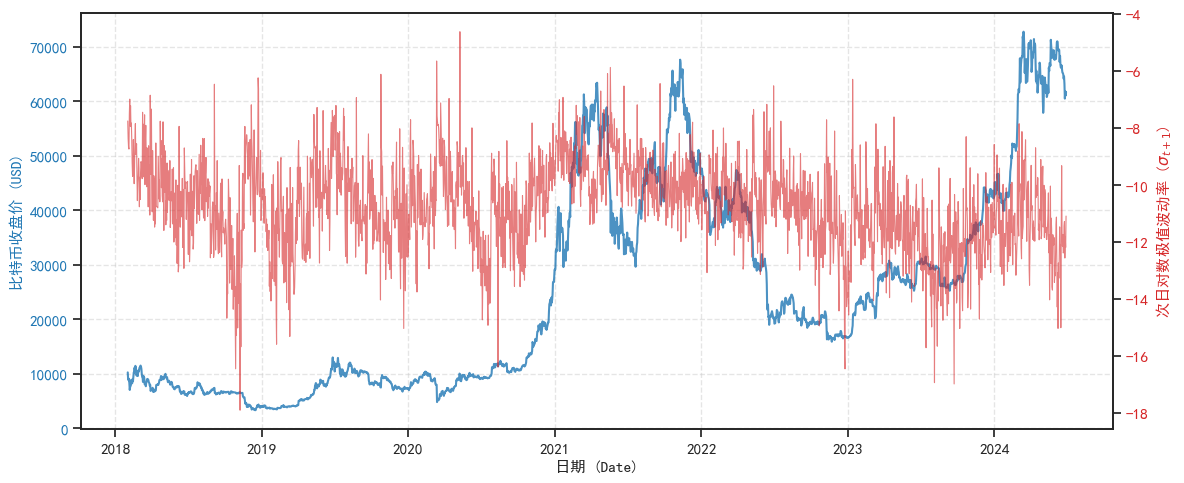

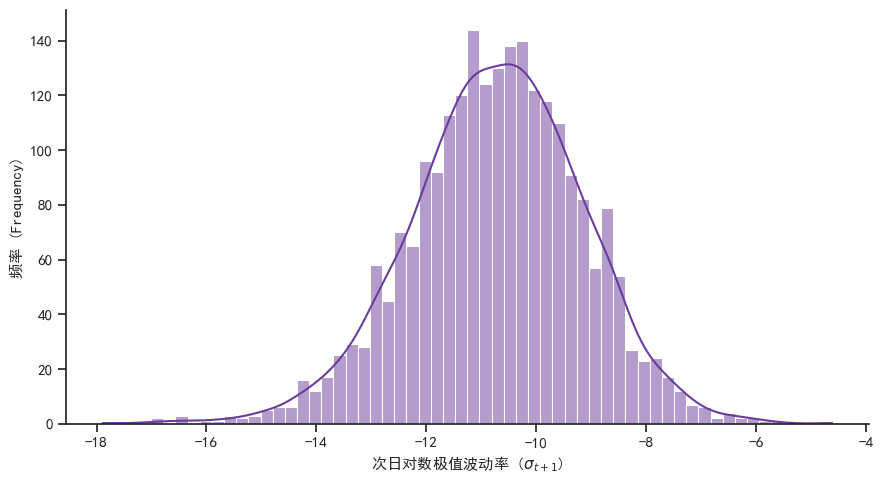

--------------------------------------------------
可视化任务已完成，生成的图片已移除原生标题以适配 Word 题注。
已保存 PNG 和 PDF 矢量图至 ../results/ 目录：
1. 3_1_volatility_timeseries.png
2. 3_2_volatility_distribution.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import fontManager

# 1. 先设置 Seaborn 主题
sns.set_theme(style="ticks")

# 2. 强行刷新并指定中文字体（按优先级排序）
# Windows 常用：SimHei (黑体), Microsoft YaHei (微软雅黑), SimSun (宋体)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 修复负号显示

# 3. (可选) 打印一下当前系统实际调用的字体，用于排查
print(f"当前生效字体: {plt.rcParams['font.sans-serif'][0]}")


# ==========================================
# 1. 数据加载
# ==========================================
data_path = '../data/01_preprocessed_data.csv'
if not os.path.exists(data_path):
    print(f"错误：找不到文件 {data_path}，请确保已运行上一步预处理代码。")
else:
    df = pd.read_csv(data_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # 确保结果文件夹存在
    os.makedirs('../results', exist_ok=True)

    # ==========================================
    # 2. 图 3-1: BTC 收盘价与次日对数波动率时序对比图
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # 左侧 Y 轴：收盘价
    color_price = '#1f77b4' # 经典深蓝色
    ax1.set_xlabel('日期 (Date)', fontsize=11)
    ax1.set_ylabel('比特币收盘价 (USD)', color=color_price, fontsize=11)
    ax1.plot(df['timestamp'], df['close'], color=color_price, linewidth=1.5, alpha=0.8, label='收盘价')
    ax1.tick_params(axis='y', labelcolor=color_price)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 右侧 Y 轴：波动率
    ax2 = ax1.twinx()  
    color_vol = '#d62728' # 经典深红色
    ax2.set_ylabel('次日对数极值波动率 ($\sigma_{t+1}$)', color=color_vol, fontsize=11)
    ax2.plot(df['timestamp'], df['target_sigma_t_plus_1'], color=color_vol, linewidth=0.8, alpha=0.6, label='对数波动率')
    ax2.tick_params(axis='y', labelcolor=color_vol)

    # 调整布局，确保不遮挡标签
    fig.tight_layout()

    # 保存图表 3-1（不含标题，符合排版规范）
    save_path_31 = '../results/3_1_volatility_timeseries.png'
    plt.savefig(save_path_31, dpi=300, bbox_inches='tight')
    plt.savefig(save_path_31.replace('.png', '.pdf'), bbox_inches='tight') # 同时保存 PDF 矢量格式
    plt.show()

    # ==========================================
    # 3. 图 3-2: 目标变量的分布特征图 (KDE + Histogram)
    # ==========================================
    plt.figure(figsize=(9, 5))

    # 绘制分布图
    sns.histplot(df['target_sigma_t_plus_1'], bins=60, kde=True, color='#6a3d9a', edgecolor='white')

    # 坐标轴标签中文化
    plt.xlabel('次日对数极值波动率 ($\sigma_{t+1}$)', fontsize=11)
    plt.ylabel('频率 (Frequency)', fontsize=11)
    sns.despine() # 移除顶部和右侧刻度线

    plt.tight_layout()

    # 保存图表 3-2
    save_path_32 = '../results/3_2_volatility_distribution.png'
    plt.savefig(save_path_32, dpi=300, bbox_inches='tight')
    plt.savefig(save_path_32.replace('.png', '.pdf'), bbox_inches='tight')
    plt.show()

    print("-" * 50)
    print(f"可视化任务已完成，生成的图片已移除原生标题以适配 Word 题注。")
    print(f"已保存 PNG 和 PDF 矢量图至 ../results/ 目录：")
    print(f"1. 3_1_volatility_timeseries.png")
    print(f"2. 3_2_volatility_distribution.png")

### 2. FinBERT 情感因子提取 (耗时警告！跑完后不再运行)

In [6]:
df_temp3 = pd.read_csv('../data/01_preprocessed_data.csv', nrows=3)
print(df_temp3.columns.tolist())

['timestamp', 'open', 'close', 'high', 'low', 'volume', 'blocks-size', 'avg-block-size', 'n-transactions-total', 'n-transactions-per-block', 'hash-rate', 'difficulty', 'miners-revenue', 'transaction-fees-usd', 'n-unique-addresses', 'n-transactions', 'estimated-transaction-volume-usd', 'total-bitcoins', 'market-cap', 'fng_value', 'fng_value_classification', 'fng_sentiment', 'cbbi_value', 'cbbi_sentiment', 'cointelegraph', 'bitcoin_news', 'reddit', 'avg_current_price', 'avg_next_price', 'pct_price_change', 'trend', 'reasoning_text', 'sentiment_class', 'action_class', 'action_score', 'target_sigma_t_plus_1']


In [7]:
import pandas as pd
import numpy as np
import torch
import ast
import gc
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# 1. 硬件自适应配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的设备: {device}")

# 2. 读取预处理后的数据
# 路径规范：从 ../data/ 读取
input_path = '../data/01_preprocessed_data.csv'
df = pd.read_csv(input_path)

# 3. 列表解析 (防坑处理)
# CSV 存储列表会变成字符串，使用 ast.literal_eval 还原为 Python List
list_columns = ['cointelegraph', 'bitcoin_news', 'reddit']
for col in list_columns:
    # 增加类型检查，防止重复运行报错或处理 NaN
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print(f"数据加载完成，总行数: {df.shape[0]}")

当前使用的设备: cuda
数据加载完成，总行数: 2337


In [8]:
# 4. 加载 FinBERT 模型与分词器
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval() # 切换至推理模式

def get_sentiment_score(texts, batch_size=16):
    """
    核心情感计算逻辑 (方案 A)
    Score = P(Positive) - P(Negative)
    """
    if not texts:
        return 0.0
    
    scores = []
    # 按照 batch_size 进一步分段，严防大文本量导致 OOM
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        
        # 文本截断与对齐 (FinBERT 最大长度 512)
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                           max_length=512, return_tensors="pt").to(device)
        
        with torch.no_grad(): # 禁用梯度计算，节省显存
            outputs = model(**inputs)
            # 对模型输出进行 Softmax 归一化得到概率
            probs = F.softmax(outputs.logits, dim=-1) 
            
            # FinBERT 标签映射通常为: 0: positive, 1: negative, 2: neutral
            # 注意：实际映射请以模型 config 为准，ProsusAI/finbert 默认为 [Pos, Neg, Neu]
            pos_probs = probs[:, 0].cpu().numpy()
            neg_probs = probs[:, 1].cpu().numpy()
            
            # 计算单条 Score = P(Pos) - P(Neg)
            batch_scores = pos_probs - neg_probs
            scores.extend(batch_scores.tolist())
            
        # 显存清理：手动删除 batch 变量并清理缓存
        del inputs, outputs, probs
        
    return np.mean(scores) if scores else 0.0

# 5. 执行每日文本聚合与情感打分
finbert_scores = []

# 使用 tqdm 打印外层日期进度条
for index, row in tqdm(df.iterrows(), total=len(df), desc="提取 FinBERT 情感因子"):
    # 聚合当天所有文本源
    daily_texts = []
    # reddit 结构较为特殊，通常是嵌套列表中的文本，这里假设已预处理为 List of strings
    # 如果 reddit 列是嵌套的 [author, text, score...]，需在此处取 index=1 的位置
    for col in list_columns:
        content = row[col]
        if isinstance(content, list):
            # 处理嵌套情况（如 reddit 常见的 [[user, text, ...], ...]）
            for item in content:
                if isinstance(item, list) and len(item) > 1:
                    daily_texts.append(str(item[4])) # 根据你提供的 sample50，正文在索引 4
                elif isinstance(item, str):
                    daily_texts.append(item)
    
    # 执行打分
    if not daily_texts:
        score = 0.0
    else:
        score = get_sentiment_score(daily_texts)
    
    finbert_scores.append(score)
    
    # 每一行处理完或每隔一定频率执行显存深度清理
    if index % 10 == 0:
        torch.cuda.empty_cache()
        gc.collect()

# 将结果填回 DataFrame
df['finbert_sentiment_score'] = finbert_scores

提取 FinBERT 情感因子: 100%|██████████| 2337/2337 [04:12<00:00,  9.25it/s]


In [9]:
# 6. 保存特征工程后的数据集
output_path = '../data/02_finbert_features_added.csv'
df.to_csv(output_path, index=False)

print("\n--- 特征提取完成 ---")
print(f"文件已保存至: {output_path}")

# 7. 检查前 10 行结果
print(df[['timestamp', 'finbert_sentiment_score']].head(10))

# 8. 技术上下文接力摘要
"""
【技术上下文接力摘要】
产出文件：../data/02_finbert_features_added.csv
Data Shape: (2337, 37)  # 新增了 finbert_sentiment_score
超参数：batch_size=16, max_length=512, model=ProsusAI/finbert
遗留问题：由于 reddit 原始数据中可能存在空列表或非字符串格式，已在代码中加入安全过滤。
         下一阶段将进行 LLM (Llama/Qwen) 情感因子提取。
"""


--- 特征提取完成 ---
文件已保存至: ../data/02_finbert_features_added.csv
    timestamp  finbert_sentiment_score
0  2018-02-01                -0.096697
1  2018-02-02                -0.079304
2  2018-02-03                -0.052735
3  2018-02-04                -0.068640
4  2018-02-05                -0.139091
5  2018-02-06                -0.082391
6  2018-02-07                -0.049396
7  2018-02-08                -0.105297
8  2018-02-09                -0.091154
9  2018-02-10                -0.062107


'\n【技术上下文接力摘要】\n产出文件：../data/02_finbert_features_added.csv\nData Shape: (2337, 37)  # 新增了 finbert_sentiment_score\n超参数：batch_size=16, max_length=512, model=ProsusAI/finbert\n遗留问题：由于 reddit 原始数据中可能存在空列表或非字符串格式，已在代码中加入安全过滤。\n         下一阶段将进行 LLM (Llama/Qwen) 情感因子提取。\n'

#### 2.5 LLM情绪因子基础处理

In [ ]:
import pandas as pd

# 1. 设置文件路径（遵循项目相对路径规范）
input_path = '../data/02_finbert_features_added.csv'

# 2. 读取数据
try:
    df = pd.read_csv(input_path)
    print(f"✅ 成功读取文件，当前数据集维度 (Shape): {df.shape}")
except FileNotFoundError:
    print(f"❌ 错误：未找到文件 {input_path}，请确认上一步 FinBERT 脚本是否运行成功。")

# 3. 定义 LLM 核心字段
llm_fields = ['sentiment_class', 'action_class', 'action_score']

print("\n" + "="*50)
print("【LLM 核心字段检查报告】")
print("="*50)

# 4. 检查字段是否存在及非空值统计
for col in llm_fields:
    if col in df.columns:
        non_null_count = df[col].notna().sum()
        total_rows = len(df)
        null_count = total_rows - non_null_count
        print(f"字段 [{col:15}]: 状态 = ✅ 存在 | 非空值 = {non_null_count} | 缺失值 = {null_count}")
    else:
        print(f"字段 [{col:15}]: 状态 = ❌ 缺失")

# 5. 打印类别分布 (针对 sentiment_class 和 action_class)
categorical_fields = ['sentiment_class', 'action_class']
for col in categorical_fields:
    if col in df.columns:
        print(f"\n--- [{col}] 类别及数量分布 ---")
        # value_counts 会统计各个类别的数量，dropna=False 确保 NaN 也能显示出来
        distribution = df[col].value_counts(dropna=False)
        print(distribution)

# 6. 检查 action_score 的数值范围（作为参考）
if 'action_score' in df.columns:
    print(f"\n--- [action_score] 数值摘要 ---")
    print(df['action_score'].describe()[['min', '25%', '50%', '75%', 'max']])



# 技术上下文接力摘要
"""
【技术上下文接力摘要】
产出文件：../data/02_finbert_features_added.csv (已验证)
Data Shape: (2337, 37)
核心字段：
 - FinBERT特征: finbert_sentiment_score (Float)
 - LLM特征: sentiment_class (Categorical), action_class (Categorical), action_score (Float)

"""

✅ 成功读取文件，当前数据集维度 (Shape): (2337, 37)

【LLM 核心字段检查报告】
字段 [sentiment_class]: 状态 = ✅ 存在 | 非空值 = 2337 | 缺失值 = 0
字段 [action_class   ]: 状态 = ✅ 存在 | 非空值 = 2337 | 缺失值 = 0
字段 [action_score   ]: 状态 = ✅ 存在 | 非空值 = 2337 | 缺失值 = 0

--- [sentiment_class] 类别及数量分布 ---
sentiment_class
positive    1031
neutral      881
negative     425
Name: count, dtype: int64

--- [action_class] 类别及数量分布 ---
action_class
hold    1718
buy      526
sell      93
Name: count, dtype: int64

--- [action_score] 数值摘要 ---
min     5.0
25%     6.0
50%     6.0
75%     8.0
max    10.0
Name: action_score, dtype: float64


'\n【技术上下文接力摘要】\n产出文件：../data/02_finbert_features_added.csv (已验证)\nData Shape: (2337, 37)\n核心字段：\n - FinBERT特征: finbert_sentiment_score (Float)\n - LLM特征: sentiment_class (Categorical), action_class (Categorical), action_score (Float)\n\n'

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================
# 0. 环境与排版配置
# ==========================================
# 确保结果保存目录存在
os.makedirs('../results', exist_ok=True)

# 强制配置 Seaborn 主题，并在主题中直接注入中文字体，防止被覆盖
sns.set_theme(style="ticks", font='SimHei')
# 修复 Windows 下负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  

# 读取数据
input_path = '../data/02_finbert_features_added.csv'
df = pd.read_csv(input_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 平滑处理：计算 7 天移动平均以便于时序图展示
df['finbert_ma7'] = df['finbert_sentiment_score'].rolling(window=7).mean()
if 'action_score' in df.columns:
    df['action_score_ma7'] = df['action_score'].rolling(window=7).mean()

# ==========================================
# 图 3-1：LLM 类别特征分布图
# ==========================================
fig1, (ax1_1, ax1_2) = plt.subplots(1, 2, figsize=(12, 5))

if 'sentiment_class' in df.columns:
    sns.countplot(data=df, x='sentiment_class', ax=ax1_1, palette='muted')
    ax1_1.set_xlabel('情感类别 (Sentiment Class)')
    ax1_1.set_ylabel('频数 (Frequency)')
    ax1_1.tick_params(axis='x', rotation=45)
    # 移除可能由 seaborn 自动生成的标题
    ax1_1.set_title("") 

if 'action_class' in df.columns:
    sns.countplot(data=df, x='action_class', ax=ax1_2, palette='muted')
    ax1_2.set_xlabel('行动类别 (Action Class)')
    ax1_2.set_ylabel('频数 (Frequency)')
    ax1_2.tick_params(axis='x', rotation=45)
    ax1_2.set_title("")

plt.tight_layout()
plt.savefig('../results/3_1_llm_categorical_dist.png', bbox_inches='tight', dpi=300)
plt.close(fig1)


# ==========================================
# 图 3-2：FinBERT 情感分数与 LLM 行动得分时间序列对比
# ==========================================
fig2, ax2_1 = plt.subplots(figsize=(14, 5))

color_left = 'tab:blue'
ax2_1.set_xlabel('日期 (Date)')
ax2_1.set_ylabel('FinBERT 情感得分 (FinBERT Score)', color=color_left)
ax2_1.plot(df['timestamp'], df['finbert_ma7'], color=color_left, alpha=0.8, label='FinBERT (7D MA)')
ax2_1.tick_params(axis='y', labelcolor=color_left)

ax2_2 = ax2_1.twinx()  
color_right = 'tab:orange'
ax2_2.set_ylabel('LLM 行动得分 (LLM Action Score)', color=color_right)
if 'action_score_ma7' in df.columns:
    ax2_2.plot(df['timestamp'], df['action_score_ma7'], color=color_right, alpha=0.8, label='LLM Action Score (7D MA)')
ax2_2.tick_params(axis='y', labelcolor=color_right)

# 设置 X 轴日期格式
ax2_1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 合并图例并放置在不遮挡数据的位置
lines_1, labels_1 = ax2_1.get_legend_handles_labels()
lines_2, labels_2 = ax2_2.get_legend_handles_labels()
ax2_1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('../results/3_2_sentiment_timeseries.png', bbox_inches='tight', dpi=300)
plt.close(fig2)


# ==========================================
# 图 3-3：情绪因子与次日波动率相关性热力图
# ==========================================
cols_to_corr = ['finbert_sentiment_score', 'target_sigma_t_plus_1']
# 重命名列以便于在热力图上直接显示规范的中英文标签
rename_dict = {
    'finbert_sentiment_score': 'FinBERT 情绪 ($S_{FB}$)',
    'target_sigma_t_plus_1': '次日对数波动率 ($\sigma_{t+1}$)'
}
if 'action_score' in df.columns:
    cols_to_corr.append('action_score')
    rename_dict['action_score'] = 'LLM 行动得分 ($S_{LLM}$)'

# 计算相关系数并重命名 index 和 columns
corr_matrix = df[cols_to_corr].rename(columns=rename_dict).corr()

fig3, ax3 = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', 
            linewidths=0.5, ax=ax3, square=True, cbar_kws={"shrink": .8})

ax3.set_title("") # 严禁原生标题
# 旋转 y 轴标签防止文字纵向截断
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../results/3_3_sentiment_correlation.png', bbox_inches='tight', dpi=300)
plt.close(fig3)


# ==========================================
# 图 3-4：目标变量 \sigma_{t+1} 的 ACF 与 PACF
# ==========================================
# 提取目标波动率并剔除 NaN
target_series = df['target_sigma_t_plus_1'].dropna()

fig4, (ax4_1, ax4_2) = plt.subplots(1, 2, figsize=(14, 5))

# 绘制 ACF，强制 title="" 屏蔽 statsmodels 默认标题
plot_acf(target_series, ax=ax4_1, lags=30, alpha=0.05, title="")
ax4_1.set_xlabel('滞后阶数 (Lags)')
ax4_1.set_ylabel('自相关系数 (ACF)')

# 绘制 PACF，强制 title="" 屏蔽默认标题
plot_pacf(target_series, ax=ax4_2, lags=30, alpha=0.05, method='ywm', title="")
ax4_2.set_xlabel('滞后阶数 (Lags)')
ax4_2.set_ylabel('偏自相关系数 (PACF)')

# 去除多余的边框（适配 ticks 主题美学）
sns.despine(fig=fig4)

plt.tight_layout()
plt.savefig('../results/3_4_target_acf_pacf.png', bbox_inches='tight', dpi=300)
plt.close(fig4)

print("✅ 所有图表均已严格按照盲审/答辩排版规范生成并保存至 ../results/ 目录。")

C:\Users\iocto\AppData\Local\Temp\ipykernel_24308\3125638799.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_class', ax=ax1_1, palette='muted')
C:\Users\iocto\AppData\Local\Temp\ipykernel_24308\3125638799.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='action_class', ax=ax1_2, palette='muted')


✅ 所有图表均已严格按照盲审/答辩排版规范生成并保存至 ../results/ 目录。


📈 ACF & PACF 深度解读
1. ACF（自相关函数）：

表现：呈现典型的“拖尾”特征，即便到了 30 阶（Lags），相关系数依然显著大于 0。

结论：这科学地证明了比特币波动率具有强烈的长记忆性和波动聚集性（即高波动后往往紧跟高波动）。这说明使用 LSTM/Bi-LSTM 这种擅长处理长时序依赖的模型是非常明智的选择。

2. PACF（偏自相关函数）：

表现：在 1-5 阶 处有非常显著的脉冲，随后迅速“截尾”并进入蓝色阴影（置信区间）区域。

结论：这意味着预测“明天”的波动率，过去 5 天左右 的历史信息提供了最核心的解释力。

3. 超参数决策建议
基于这张图，我们可以科学地设定 滑动窗口大小（Lookback Window / Time Steps）：

建议窗口大小：7 或 10

理由：虽然 PACF 在 5 阶后截尾，但在加密货币这种 7x24 小时交易的市场，选取 7（一个完整周周期）或 10（包含更多情绪发酵缓冲）能让 Bi-LSTM 学习到更稳健的特征。

论文写作亮点：你可以在第四章写道：“经 PACF 检验发现波动率在 5 阶内显著相关，结合加密货币市场周周期特性，本文最终将滑动窗口设定为 7。”

### 3. 特征工程

In [5]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import os

# ==========================================
# 全局环境与硬件自适应检测
# ==========================================
# 严格遵守算力红线，检测并锁定 RTX 4060 (CUDA 12.1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前计算设备锁定为: {device}")
if device.type == 'cuda':
    print(f"显卡型号: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache() # 初始化时清理可能存在的显存碎片

# ==========================================
# 步骤 1：数据读取与类别特征数值化 (Encoding)
# ==========================================
# 严格按照物理路径规范读取最新检查点
data_path = '../data/02_finbert_features_added.csv'
if not os.path.exists(data_path):
    print(f"警告: 找不到文件 {data_path}，请确保上一阶段的数据已正确保存。")

df = pd.read_csv(data_path)

# 确保 timestamp 为时间格式，并按时间严格排序，防止时序错乱
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

# 类别特征映射字典
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
action_map = {'buy': 1, 'hold': 0, 'sell': -1}

# 执行映射 (如果列存在的话)
if 'sentiment_class' in df.columns:
    df['sentiment_class'] = df['sentiment_class'].map(sentiment_map)
if 'action_class' in df.columns:
    df['action_class'] = df['action_class'].map(action_map)

print("\n步骤 1 完成：类别特征已成功数值化。")

# ==========================================
# 步骤 2：产出论文所需的“三线表”统计数据
# ==========================================
# 在进行任何数据缩放(Scaling)之前，提取原始特征的统计分布用于论文撰写
cols_for_stats = [
    'close', 'volume', 'target_sigma_t_plus_1', 
    'finbert_sentiment_score', 'action_score', 
    'sentiment_class', 'action_class'
]

# 过滤出当前 DataFrame 中实际存在的列（防止某些列名微调导致报错）
existing_stats_cols = [col for col in cols_for_stats if col in df.columns]

print("\n" + "="*50)
print("步骤 2：论文三线表所需原始统计数据 (缩放前)")
print("="*50)
stats_df = df[existing_stats_cols].describe().T
# 格式化输出，方便直接填入论文三线表 (保留4位小数)
print(stats_df[['count', 'mean', 'std', 'min', 'max']].round(4))
print("="*50 + "\n")

# ==========================================
# 步骤 3：严格防穿越的数据标准化 (Scaling)
# ==========================================
# 按时间顺序，取前 80% 数据的切分点索引
split_idx = int(len(df) * 0.8)
print(f"时序数据集划分点索引 (80%): {split_idx} / {len(df)}")

# 定义不需要进行 StandardScale 的列（时间戳和目标标签绝不缩放）
exclude_cols = ['timestamp', 'target_sigma_t_plus_1']

# 筛选出所有需要进行标准化的纯数值特征列
feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# 实例化 StandardScaler
scaler = StandardScaler()

# 【核心红线】：只使用前 80% (训练集区间) 的特征去 fit()，计算均值和方差，绝对防止未来数据泄露！
scaler.fit(df.loc[:split_idx-1, feature_cols])

# 复制原数据框，避免直接在原数据上修改引发隐式警告
df_scaled = df.copy()

# 使用训练集 fit 好的 scaler 对整张表 (前 80% + 后 20%) 进行 transform()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

print("步骤 3 完成：已执行严格防穿越特征标准化。")

# ==========================================
# 步骤 4：保存最终特征矩阵
# ==========================================
# 确保结果保存目录存在
os.makedirs('../data', exist_ok=True)
save_path = '../data/03_final_feature_matrix.csv'

# 保存特征矩阵
df_scaled.to_csv(save_path, index=False)
print(f"\n步骤 4 完成：特征矩阵已保存至 {save_path}")

# 打印最终 Shape 及尾部数据供检查
print(f"\n最终 df_scaled 的数据维度 (Shape): {df_scaled.shape}")
print("\n末尾 5 行数据预览 (缩放后):")
display(df_scaled.tail()) # 如果在纯 Python 脚本中运行可改为 print(df_scaled.tail())



# 检查LLM列的unique值数量和分布
for col in ['sentiment_class', 'action_class', 'action_score']:
    print(f"\n{col}:")
    print(f"  unique值数量: {df[col].nunique()}")
    print(f"  值分布:\n{df[col].value_counts()}")


# 交叉表：sentiment vs action
ct = pd.crosstab(df['sentiment_class'], df['action_class'], 
                  margins=True, margins_name='Total')
print(ct)

# 相关系数
print("\n三列相关系数：")
print(df[['sentiment_class', 'action_class', 'action_score']].corr())

当前计算设备锁定为: cuda
显卡型号: NVIDIA GeForce RTX 4060 Laptop GPU

步骤 1 完成：类别特征已成功数值化。

步骤 2：论文三线表所需原始统计数据 (缩放前)
                          count        mean         std        min         max
close                    2337.0  24791.2079  18646.9884  3284.1000  72774.0000
volume                   2337.0    460.2809   1001.7336     0.8564  16776.5967
target_sigma_t_plus_1    2337.0    -10.7194      1.5724   -17.8925     -4.6174
finbert_sentiment_score  2337.0     -0.0561      0.0261    -0.1685      0.0116
action_score             2337.0      6.8169      1.0282     5.0000     10.0000
sentiment_class          2337.0      0.2593      0.7457    -1.0000      1.0000
action_class             2337.0      0.1853      0.4802    -1.0000      1.0000

时序数据集划分点索引 (80%): 1869 / 2337
步骤 3 完成：已执行严格防穿越特征标准化。

步骤 4 完成：特征矩阵已保存至 ../data/03_final_feature_matrix.csv

最终 df_scaled 的数据维度 (Shape): (2337, 37)

末尾 5 行数据预览 (缩放后):


,timestamp,open,close,high,low,volume,blocks-size,avg-block-size,n-transactions-total,n-transactions-per-block,...,avg_current_price,avg_next_price,pct_price_change,trend,reasoning_text,sentiment_class,action_class,action_score,target_sigma_t_plus_1,finbert_sentiment_score
2332,2024-06-24,2.552394,2.544408,2.532464,2.564258,-0.415534,3.118322,1.939287,3.037230,4.271867,...,2.548396,2.383529,-1.164964,down,The news and Reddit posts contain a mix of pos...,-1.579969,-0.315145,-0.765074,-11.273785,0.783048
2333,2024-06-25,2.378009,2.383878,2.372552,2.401186,-0.461040,3.121025,1.774667,3.040608,6.579660,...,2.383922,2.465226,0.555165,up,The news and Reddit posts are mixed. Some news...,-0.271032,-0.315145,-0.765074,-12.555604,1.131814
2334,2024-06-26,2.467978,2.465098,2.444863,2.484526,-0.489791,3.123179,1.984457,3.044061,5.848816,...,2.465614,2.413915,-0.393892,same,The news and Reddit posts contain a mix of pos...,-0.271032,-0.315145,-0.765074,-11.814030,1.009578
2335,2024-06-27,2.411381,2.417774,2.397031,2.431010,-0.482075,3.125353,2.179487,3.047175,3.493829,...,2.414307,2.457689,0.279609,same,The news and Reddit posts contain a mix of pos...,-0.271032,-0.315145,-0.765074,-12.184682,0.962181
2336,2024-06-28,2.463560,2.453043,2.439232,2.476468,-0.484269,3.127754,2.014913,3.049843,6.782045,...,2.458078,2.397692,-0.455885,same,The news and Reddit posts contain a mix of pos...,-0.271032,-0.315145,-0.765074,-11.084055,0.980341



sentiment_class:
  unique值数量: 3
  值分布:
sentiment_class
 1    1031
 0     881
-1     425
Name: count, dtype: int64

action_class:
  unique值数量: 3
  值分布:
action_class
 0    1718
 1     526
-1      93
Name: count, dtype: int64

action_score:
  unique值数量: 6
  值分布:
action_score
6.0     1128
8.0      498
7.0      483
9.0      162
5.0       64
10.0       2
Name: count, dtype: int64
action_class     -1     0    1  Total
sentiment_class                      
-1               93   331    1    425
0                 0   881    0    881
1                 0   506  525   1031
Total            93  1718  526   2337

三列相关系数：
                 sentiment_class  action_class  action_score
sentiment_class         1.000000      0.603346      0.594630
action_class            0.603346      1.000000      0.506545
action_score            0.594630      0.506545      1.000000


### 4. 模型搭建与训练